# Atobb vs TTLJ XGBoost Training and ONNX Export

This notebook trains a first-pass XGBoost classifier using the `Training_Tree` produced by `AtobbMLTree`.

- Signal: `TTToHcToWAToBB-MHc100_MA60.root` by default
- Background: `TTLJ_powheg.root` by default
- Main weight: `weight_train`
- Output model: `xgboost_atobb_ttlJ.onnx`

Before running, check that the ROOT paths below match your actual output directory.


## 1. Imports

Run this in the `MLHEP` kernel/environment where `ROOT`, `xgboost`, `onnxmltools`, and `skl2onnx` are installed.


In [1]:
import os
import json
import numpy as np
import pandas as pd
import ROOT
import xgboost as xgb
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc, accuracy_score, confusion_matrix

import onnx
from onnxmltools.convert import convert_xgboost as convert_xgboost_booster
from skl2onnx.common.data_types import FloatTensorType


## 2. Input ROOT files

Change these paths if your files are somewhere else.


In [2]:
BASE_DIR = "/data9/Users/eunsu/SKNanoOutput/AtobbMLTree/2024"

SIG_FILES = [
    f"{BASE_DIR}/TTToHcToWAToBB-MHc100_MA60.root",
]

BKG_FILES = [
    f"{BASE_DIR}/TTLJ_powheg.root",
]

TREE_NAME = "Training_Tree"

MODEL_DIR = "/data9/Users/eunsu/MachineLearning/models"
os.makedirs(MODEL_DIR, exist_ok=True)

ONNX_PATH = f"{MODEL_DIR}/xgboost_atobb_ttlJ.onnx"
FEATURE_JSON_PATH = f"{MODEL_DIR}/xgboost_atobb_ttlJ_features.json"

print("Signal files:")
for p in SIG_FILES:
    print("  ", p, os.path.exists(p))
print("Background files:")
for p in BKG_FILES:
    print("  ", p, os.path.exists(p))


Signal files:
   /data9/Users/eunsu/SKNanoOutput/AtobbMLTree/2024/TTToHcToWAToBB-MHc100_MA60.root True
Background files:
   /data9/Users/eunsu/SKNanoOutput/AtobbMLTree/2024/TTLJ_powheg.root True


## 3. Load ROOT tree into pandas

This function reads only the branches we need, which is faster and safer than reading everything.


In [3]:
def read_training_tree(files, tree_name="Training_Tree", branches=None):
    dfs = []
    for path in files:
        if not os.path.exists(path):
            raise FileNotFoundError(path)
        f = ROOT.TFile.Open(path, "READ")
        if not f or f.IsZombie():
            raise RuntimeError(f"Cannot open ROOT file: {path}")
        tree = f.Get(tree_name)
        if not tree:
            raise RuntimeError(f"Cannot find tree '{tree_name}' in {path}")
        rdf = ROOT.RDataFrame(tree)
        if branches is None:
            arr = rdf.AsNumpy()
        else:
            arr = rdf.AsNumpy(branches)
        df = pd.DataFrame(arr)
        df["source_file"] = os.path.basename(path)
        dfs.append(df)
        f.Close()
    return pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()


## 4. Feature list

First-pass feature set. These are physics-motivated variables from `AtobbMLTree`: jet activity, b-tag topology, bb-pair masses, and ttbar reconstruction variables.

Do **not** include `label`, `weight_*`, or `source_file` as ML inputs.


In [4]:
FEATURES = [
    # event-level activity
    "HT", "ST", "MET_Pt",

    # multiplicity / topology
    "nJets", "nBJets",

    # leading jets by pT
    "Jet0_Pt", "Jet1_Pt", "Jet2_Pt", "Jet3_Pt", "Jet4_Pt", "Jet5_Pt",
    "Jet0_Eta", "Jet1_Eta", "Jet2_Eta", "Jet3_Eta", "Jet4_Eta", "Jet5_Eta",
    "Jet0_M", "Jet1_M", "Jet2_M", "Jet3_M", "Jet4_M", "Jet5_M",

    # b-tag scores / flags
    "Jet0_Bscore", "Jet1_Bscore", "Jet2_Bscore", "Jet3_Bscore", "Jet4_Bscore", "Jet5_Bscore",
    "Jet0_isBtag", "Jet1_isBtag", "Jet2_isBtag", "Jet3_isBtag", "Jet4_isBtag", "Jet5_isBtag",

    # A -> bb candidates from first three b-tagged jets
    "bb_mass_01", "bb_mass_02", "bb_mass_12",
    "bb_dr_01", "bb_dr_02", "bb_dr_12",

    # ttbar reconstruction consistency
    "best_chi2", "had_W_mass", "had_top_mass", "lep_W_mass", "lep_top_mass",

    # lepton and MET
    "Muon0_Pt", "Muon0_Eta", "MET_Phi",
]

WEIGHT_COL = "weight_train"
LABEL_COL = "label"

BRANCHES_TO_READ = sorted(set(FEATURES + [WEIGHT_COL, "weight_nominal", LABEL_COL]))
print(f"Number of features = {len(FEATURES)}")


Number of features = 49


## 5. Read signal and background samples

For this notebook, we override the label explicitly to avoid relying on sample-name parsing.


In [5]:
df_sig = read_training_tree(SIG_FILES, TREE_NAME, branches=BRANCHES_TO_READ)
df_bkg = read_training_tree(BKG_FILES, TREE_NAME, branches=BRANCHES_TO_READ)

df_sig[LABEL_COL] = 1
df_bkg[LABEL_COL] = 0

print("Signal entries:", len(df_sig))
print("Background entries:", len(df_bkg))
print("Signal columns:", df_sig.columns.tolist())

df_sig.head()


Signal entries: 2512
Background entries: 740083
Signal columns: ['HT', 'Jet0_Bscore', 'Jet0_Eta', 'Jet0_M', 'Jet0_Pt', 'Jet0_isBtag', 'Jet1_Bscore', 'Jet1_Eta', 'Jet1_M', 'Jet1_Pt', 'Jet1_isBtag', 'Jet2_Bscore', 'Jet2_Eta', 'Jet2_M', 'Jet2_Pt', 'Jet2_isBtag', 'Jet3_Bscore', 'Jet3_Eta', 'Jet3_M', 'Jet3_Pt', 'Jet3_isBtag', 'Jet4_Bscore', 'Jet4_Eta', 'Jet4_M', 'Jet4_Pt', 'Jet4_isBtag', 'Jet5_Bscore', 'Jet5_Eta', 'Jet5_M', 'Jet5_Pt', 'Jet5_isBtag', 'MET_Phi', 'MET_Pt', 'Muon0_Eta', 'Muon0_Pt', 'ST', 'bb_dr_01', 'bb_dr_02', 'bb_dr_12', 'bb_mass_01', 'bb_mass_02', 'bb_mass_12', 'best_chi2', 'had_W_mass', 'had_top_mass', 'label', 'lep_W_mass', 'lep_top_mass', 'nBJets', 'nJets', 'weight_nominal', 'weight_train', 'source_file']


,HT,Jet0_Bscore,Jet0_Eta,Jet0_M,Jet0_Pt,Jet0_isBtag,Jet1_Bscore,Jet1_Eta,Jet1_M,Jet1_Pt,...,had_W_mass,had_top_mass,label,lep_W_mass,lep_top_mass,nBJets,nJets,weight_nominal,weight_train,source_file
0,301.794464,0.009771,0.981812,11.494443,92.017799,0,0.007791,1.267090,8.159320,62.480701,...,83.502190,173.332214,1,94.107941,167.248520,4,7,0.002500,0.002677,TTToHcToWAToBB-MHc100_MA60.root
1,1099.348267,0.999390,-0.874268,55.520176,345.825867,1,0.691528,-0.734619,22.093924,264.657379,...,42.123226,185.201630,1,148.563721,475.643311,4,7,0.003973,0.004254,TTToHcToWAToBB-MHc100_MA60.root
2,242.727707,0.998901,-1.749512,12.583385,59.439732,1,0.165405,-1.981934,5.717875,49.560097,...,-999.000000,-999.000000,1,-999.000000,-999.000000,5,6,0.005552,0.005337,TTToHcToWAToBB-MHc100_MA60.root
3,1209.330322,0.004582,-1.331787,42.029751,447.255371,0,0.998169,-0.341064,17.425686,219.903717,...,844.568298,1126.765381,1,77.239510,175.703339,5,8,0.003688,0.004044,TTToHcToWAToBB-MHc100_MA60.root
4,684.477966,0.998535,0.973022,32.816242,261.538330,1,0.326050,0.418030,22.409225,164.277527,...,97.998657,205.235474,1,45.142830,182.850845,4,6,0.009508,0.010181,TTToHcToWAToBB-MHc100_MA60.root


## 6. Basic cleaning and weight handling

- Replace `inf` with `NaN`
- Drop rows with invalid feature/weight values
- Use `abs(weight_train)` by default for training stability
- Normalize total signal/background weights to similar scale

If you want signed MC weights later, keep them for final histograms, but for first classifier training this is safer.


In [6]:
def clean_df(df, features, weight_col):
    use_cols = features + [LABEL_COL, weight_col]
    out = df[use_cols].copy()
    out = out.replace([np.inf, -np.inf], np.nan)
    out = out.dropna(subset=use_cols)
    out[weight_col] = out[weight_col].astype(float)
    out = out[out[weight_col] != 0]
    return out

df_sig_clean = clean_df(df_sig, FEATURES, WEIGHT_COL)
df_bkg_clean = clean_df(df_bkg, FEATURES, WEIGHT_COL)

# Use absolute training weights for first-pass ML stability.
df_sig_clean["ml_weight"] = np.abs(df_sig_clean[WEIGHT_COL].to_numpy(dtype=float))
df_bkg_clean["ml_weight"] = np.abs(df_bkg_clean[WEIGHT_COL].to_numpy(dtype=float))

# Normalize total class weights to avoid one class dominating the loss.
sig_sumw = df_sig_clean["ml_weight"].sum()
bkg_sumw = df_bkg_clean["ml_weight"].sum()

if sig_sumw <= 0 or bkg_sumw <= 0:
    print("WARNING: weight sum is non-positive. Falling back to unit weights.")
    df_sig_clean["ml_weight"] = 1.0
    df_bkg_clean["ml_weight"] = 1.0
    sig_sumw = len(df_sig_clean)
    bkg_sumw = len(df_bkg_clean)

# Make each class have approximately the same total training weight.
df_sig_clean["ml_weight"] *= 0.5 / sig_sumw
df_bkg_clean["ml_weight"] *= 0.5 / bkg_sumw

print("After cleaning:")
print("  signal entries:", len(df_sig_clean), "sum ml weight:", df_sig_clean["ml_weight"].sum())
print("  bkg entries   :", len(df_bkg_clean), "sum ml weight:", df_bkg_clean["ml_weight"].sum())


After cleaning:
  signal entries: 2512 sum ml weight: 0.5
  bkg entries   : 740083 sum ml weight: 0.4999999999999999


In [7]:
print(df_sig_clean["weight_train"].describe())
print(df_bkg_clean["weight_train"].describe())

print(df_sig_clean["weight_train"].head())
print(df_bkg_clean["weight_train"].head())

count    2512.000000
mean        0.004754
std         0.002893
min         0.001120
25%         0.003185
50%         0.003949
75%         0.005758
max         0.025334
Name: weight_train, dtype: float64
count    740083.000000
mean          0.088400
std           0.056753
min          -0.519118
25%           0.060097
50%           0.073079
75%           0.108322
max           7.024733
Name: weight_train, dtype: float64
0    0.002677
1    0.004254
2    0.005337
3    0.004044
4    0.010181
Name: weight_train, dtype: float64
0    0.080879
1    0.078851
2    0.063702
3    0.061978
4    0.095583
Name: weight_train, dtype: float64


In [8]:
df_sig_clean = df_sig_clean[df_sig_clean["weight_train"] > 0].copy()
df_bkg_clean = df_bkg_clean[df_bkg_clean["weight_train"] > 0].copy()

## 7. Quick sanity plots

These are not for final presentation, just to confirm signal/background shape differences.


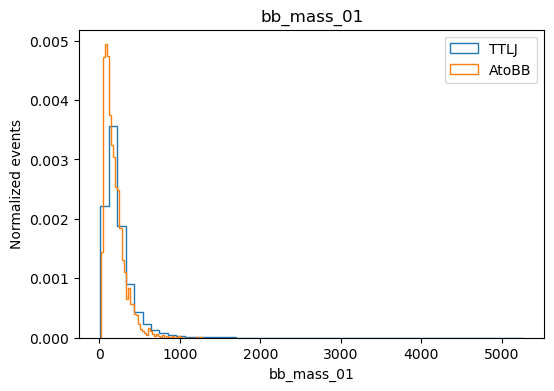

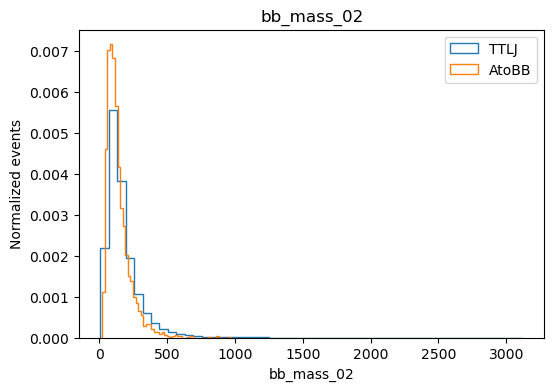

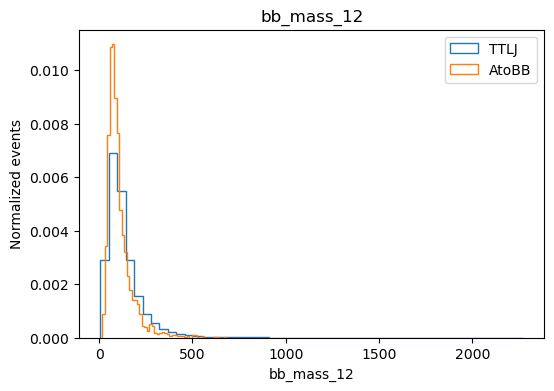

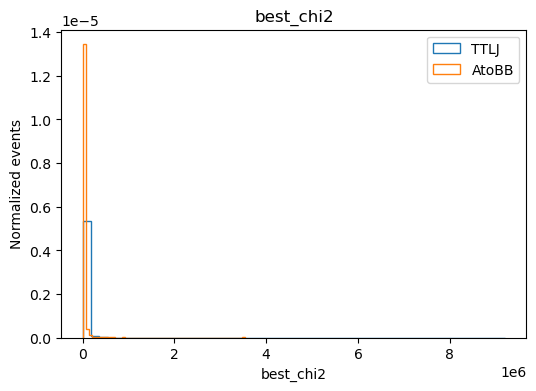

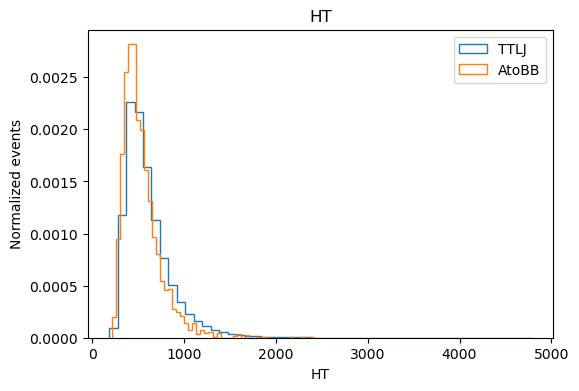

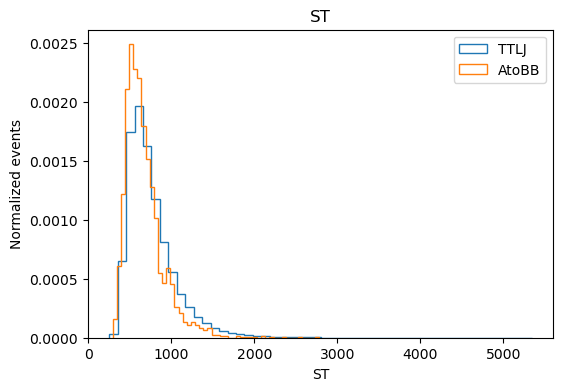

In [9]:
for var in ["bb_mass_01", "bb_mass_02", "bb_mass_12", "best_chi2", "HT", "ST"]:
    plt.figure(figsize=(6,4))
    plt.hist(df_bkg_clean[var], bins=50, histtype="step", density=True, label="TTLJ")
    plt.hist(df_sig_clean[var], bins=50, histtype="step", density=True, label="AtoBB")
    plt.xlabel(var)
    plt.ylabel("Normalized events")
    plt.legend()
    plt.title(var)
    plt.show()


## 8. Train / validation split

Use stratified split so both train and validation contain signal and background.


In [10]:
df_all = pd.concat([df_sig_clean, df_bkg_clean], ignore_index=True)

train_df, val_df = train_test_split(
    df_all,
    test_size=0.2,
    random_state=42,
    stratify=df_all[LABEL_COL],
)

X_train = train_df[FEATURES].copy()
y_train = train_df[LABEL_COL].astype(int).copy()
# w_train = train_df["ml_weight"].astype(float).copy()
w_train = np.ones(len(train_df))

X_val = val_df[FEATURES].copy()
y_val = val_df[LABEL_COL].astype(int).copy()
# w_val = val_df["ml_weight"].astype(float).copy()
w_val = np.ones(len(val_df))

used_columns = list(X_train.columns)
print("used columns:")
for i, c in enumerate(used_columns):
    print(f"  {i:02d}: {c}")

# ONNX/XGBoost conversion is safer with integer feature names.
X_train.columns = range(len(used_columns))
X_val.columns = range(len(used_columns))


used columns:
  00: HT
  01: ST
  02: MET_Pt
  03: nJets
  04: nBJets
  05: Jet0_Pt
  06: Jet1_Pt
  07: Jet2_Pt
  08: Jet3_Pt
  09: Jet4_Pt
  10: Jet5_Pt
  11: Jet0_Eta
  12: Jet1_Eta
  13: Jet2_Eta
  14: Jet3_Eta
  15: Jet4_Eta
  16: Jet5_Eta
  17: Jet0_M
  18: Jet1_M
  19: Jet2_M
  20: Jet3_M
  21: Jet4_M
  22: Jet5_M
  23: Jet0_Bscore
  24: Jet1_Bscore
  25: Jet2_Bscore
  26: Jet3_Bscore
  27: Jet4_Bscore
  28: Jet5_Bscore
  29: Jet0_isBtag
  30: Jet1_isBtag
  31: Jet2_isBtag
  32: Jet3_isBtag
  33: Jet4_isBtag
  34: Jet5_isBtag
  35: bb_mass_01
  36: bb_mass_02
  37: bb_mass_12
  38: bb_dr_01
  39: bb_dr_02
  40: bb_dr_12
  41: best_chi2
  42: had_W_mass
  43: had_top_mass
  44: lep_W_mass
  45: lep_top_mass
  46: Muon0_Pt
  47: Muon0_Eta
  48: MET_Phi


## 9. Train XGBoost model

This is a first-pass model. Tune `max_depth`, `eta`, and `num_boost_round` later.


In [11]:
dtrain = xgb.DMatrix(X_train, label=y_train, weight=w_train)
dval = xgb.DMatrix(X_val, label=y_val, weight=w_val)

params = {
    "max_depth": 4,
    "eta": 0.05,
    "objective": "binary:logistic",
    "eval_metric": "logloss",
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "random_state": 42,
    "tree_method": "hist",
    "scale_pos_weight": len(df_bkg_clean) / len(df_sig_clean)
}

evals_result = {}
model = xgb.train(
    params,
    dtrain,
    num_boost_round=1000,
    evals=[(dtrain, "train"), (dval, "validation")],
    early_stopping_rounds=20,
    evals_result=evals_result,
    verbose_eval=50,
)

print("Best iteration:", model.best_iteration)
print("Best validation logloss:", model.best_score)


[0]	train-logloss:0.68344	validation-logloss:0.68348
[50]	train-logloss:0.52242	validation-logloss:0.52323
[100]	train-logloss:0.47178	validation-logloss:0.47288
[150]	train-logloss:0.44184	validation-logloss:0.44293
[200]	train-logloss:0.41775	validation-logloss:0.41919
[250]	train-logloss:0.40104	validation-logloss:0.40272
[300]	train-logloss:0.38197	validation-logloss:0.38411
[350]	train-logloss:0.36669	validation-logloss:0.36909
[400]	train-logloss:0.35122	validation-logloss:0.35389
[450]	train-logloss:0.33808	validation-logloss:0.34097
[500]	train-logloss:0.32466	validation-logloss:0.32779
[550]	train-logloss:0.31268	validation-logloss:0.31590
[600]	train-logloss:0.30091	validation-logloss:0.30434
[650]	train-logloss:0.28956	validation-logloss:0.29322
[700]	train-logloss:0.27838	validation-logloss:0.28231
[750]	train-logloss:0.26786	validation-logloss:0.27190
[800]	train-logloss:0.25867	validation-logloss:0.26286
[850]	train-logloss:0.24962	validation-logloss:0.25408
[900]	train-l

## 10. Evaluation: ROC and score distributions


AUC = 0.8057197634077655


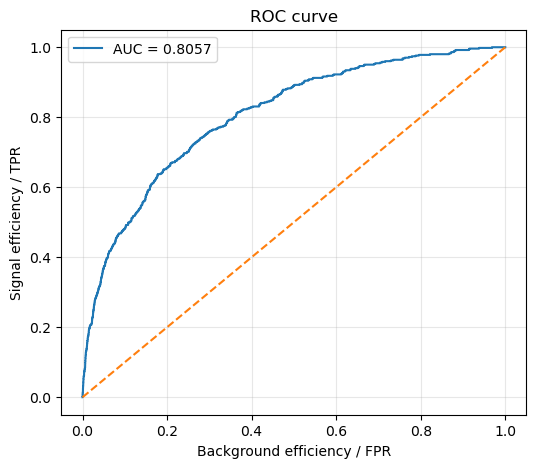

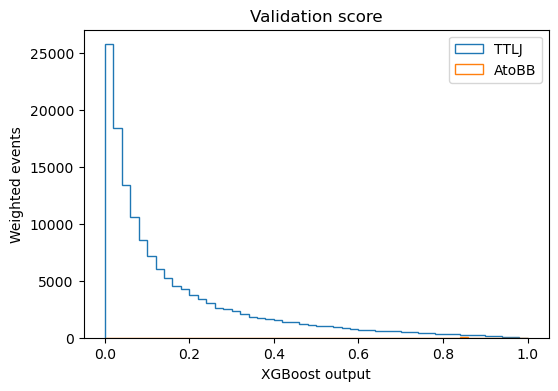

In [12]:
y_pred = model.predict(dval, iteration_range=(0, model.best_iteration + 1))

fpr, tpr, thresholds = roc_curve(y_val, y_pred, sample_weight=w_val)
roc_auc = auc(fpr, tpr)
print("AUC =", roc_auc)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("Background efficiency / FPR")
plt.ylabel("Signal efficiency / TPR")
plt.title("ROC curve")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(6,4))
plt.hist(y_pred[y_val.to_numpy() == 0], bins=50, range=(0,1), histtype="step", weights=w_val[y_val == 0], label="TTLJ")
plt.hist(y_pred[y_val.to_numpy() == 1], bins=50, range=(0,1), histtype="step", weights=w_val[y_val == 1], label="AtoBB")
plt.xlabel("XGBoost output")
plt.ylabel("Weighted events")
plt.legend()
plt.title("Validation score")
plt.show()


## 11. Overtraining check

Compare train vs validation score shapes.


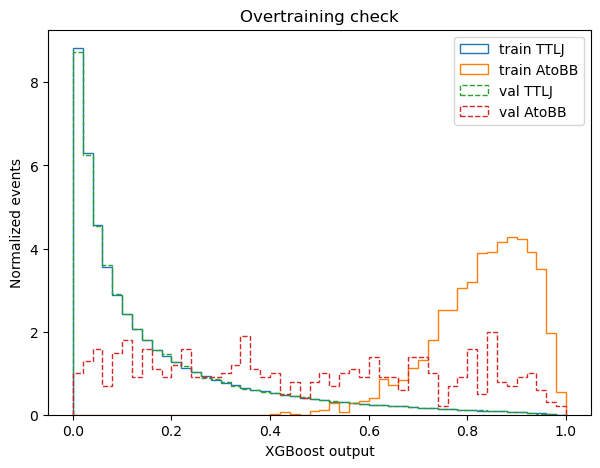

In [13]:
y_pred_train = model.predict(dtrain, iteration_range=(0, model.best_iteration + 1))

plt.figure(figsize=(7,5))
plt.hist(y_pred_train[y_train.to_numpy() == 0], bins=50, range=(0,1), histtype="step", density=True, label="train TTLJ")
plt.hist(y_pred_train[y_train.to_numpy() == 1], bins=50, range=(0,1), histtype="step", density=True, label="train AtoBB")
plt.hist(y_pred[y_val.to_numpy() == 0], bins=50, range=(0,1), histtype="step", density=True, linestyle="--", label="val TTLJ")
plt.hist(y_pred[y_val.to_numpy() == 1], bins=50, range=(0,1), histtype="step", density=True, linestyle="--", label="val AtoBB")
plt.xlabel("XGBoost output")
plt.ylabel("Normalized events")
plt.legend()
plt.title("Overtraining check")
plt.show()


## 12. Feature importance


         feature         gain
0         nBJets  1938.698730
1     bb_mass_12  1198.404663
2    Jet4_isBtag  1179.532959
3     bb_mass_01  1148.215576
4       bb_dr_02  1110.268188
5     bb_mass_02   996.494995
6    Jet3_Bscore   987.052063
7       bb_dr_01   955.894104
8    Jet2_Bscore   911.410034
9    Jet5_Bscore   903.071228
10   Jet1_isBtag   894.643250
11      bb_dr_12   891.983459
12   Jet1_Bscore   889.848755
13   Jet0_Bscore   886.906555
14      Muon0_Pt   856.479614
15   Jet4_Bscore   841.625122
16         nJets   833.245056
17   Jet2_isBtag   829.528931
18        MET_Pt   750.252808
19            ST   702.968811
20   Jet3_isBtag   701.557373
21  lep_top_mass   669.205322
22     best_chi2   660.699646
23   Jet0_isBtag   636.219971
24    lep_W_mass   629.972290
25       Jet3_Pt   628.900330
26       Jet2_Pt   617.024170
27  had_top_mass   608.937988
28       Jet4_Pt   606.261169
29    had_W_mass   603.353149


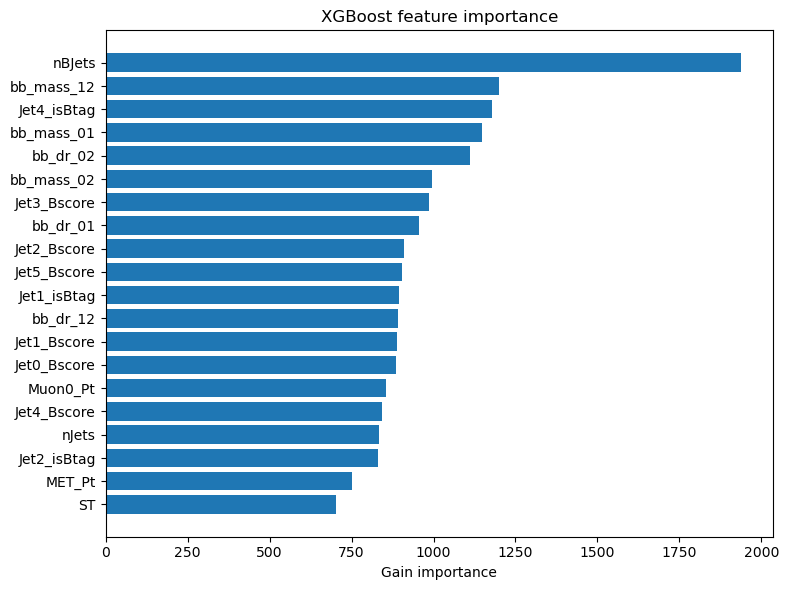

In [14]:
importance = model.get_score(importance_type="gain")
importance_named = []
for key, val in importance.items():
    # key is like f0, f1, ...
    idx = int(key[1:]) if key.startswith("f") else int(key)
    importance_named.append((used_columns[idx], val))
importance_named = sorted(importance_named, key=lambda x: x[1], reverse=True)

imp_df = pd.DataFrame(importance_named, columns=["feature", "gain"])
print(imp_df.head(30))

plt.figure(figsize=(8,6))
plot_df = imp_df.head(20).iloc[::-1]
plt.barh(plot_df["feature"], plot_df["gain"])
plt.xlabel("Gain importance")
plt.title("XGBoost feature importance")
plt.tight_layout()
plt.show()


## 13. Export to ONNX

This creates `xgboost_atobb_ttlJ.onnx` and a JSON file containing the exact feature order.

The C++ inference input vector **must use this exact order**.


In [ ]:
initial_type = [("input", FloatTensorType([None, len(used_columns)]))]
onnx_model = convert_xgboost_booster(
    model,
    initial_types=initial_type,
    target_opset=15,
)

onnx.save(onnx_model, ONNX_PATH)

feature_info = {
    "onnx_path": ONNX_PATH,
    "n_features": len(used_columns),
    "features": used_columns,
    "signal_files": SIG_FILES,
    "background_files": BKG_FILES,
    "weight_col": WEIGHT_COL,
}
with open(FEATURE_JSON_PATH, "w") as f:
    json.dump(feature_info, f, indent=2)

print("Saved ONNX:", ONNX_PATH)
print("Saved feature order:", FEATURE_JSON_PATH)


## 14. Validate ONNX output against XGBoost output

This checks that the exported ONNX model gives the same score as the original XGBoost model.


In [ ]:
import onnxruntime as ort

sess = ort.InferenceSession(ONNX_PATH, providers=["CPUExecutionProvider"])
print("ONNX inputs:", sess.get_inputs())
print("ONNX outputs:", sess.get_outputs())

X_val_np = X_val.to_numpy(dtype=np.float32)
onnx_outputs = sess.run(None, {"input": X_val_np})

# For binary:logistic conversion, output name/shape can differ by package version.
# Print shapes first.
for i, out in enumerate(onnx_outputs):
    print(i, type(out), getattr(out, "shape", None))

# Try common cases.
y_pred_onnx = None
if len(onnx_outputs) == 1:
    y_pred_onnx = np.asarray(onnx_outputs[0]).reshape(-1)
else:
    # Often: labels, probabilities. probabilities may be array or list of dicts.
    prob = onnx_outputs[-1]
    if isinstance(prob, list):
        y_pred_onnx = np.array([p[1] if 1 in p else p.get("1") for p in prob], dtype=float)
    else:
        prob = np.asarray(prob)
        if prob.ndim == 2 and prob.shape[1] >= 2:
            y_pred_onnx = prob[:, 1]
        else:
            y_pred_onnx = prob.reshape(-1)

print("ONNX pred ready:", y_pred_onnx.shape)
print("max |xgb - onnx| =", np.max(np.abs(y_pred - y_pred_onnx)))

plt.figure(figsize=(6,4))
plt.hist(np.abs(y_pred - y_pred_onnx), bins=50, histtype="step")
plt.xlabel("|XGBoost - ONNX|")
plt.ylabel("Events")
plt.title("ONNX validation")
plt.show()


## 15. C++ inference note

For SKNano C++ inference, use the exact feature order saved in `xgboost_atobb_ttlJ_features.json`.

The input shape should be:

```cpp
input_shape_xgboost["input"] = {1, N_FEATURES};
```

where `N_FEATURES` is printed above.
